# RA2T1 - Problema de Asignación de Tareas con Algoritmos Genéticos

**autor**

Febrero 2026

---
## 1. Comprensión del problema

### En qué consiste el problema

Tenemos **N trabajadores** y **N tareas**. Cada trabajador tiene un coste diferente para hacer cada tarea, y esos costes vienen en una **matriz de costes**. Lo que hay que hacer es asignar una tarea a cada trabajador de forma que cada tarea la haga solo un trabajador y que el **coste total sea el mínimo posible**.

Es bastante parecido al Problema del Viajero de la Sesión 3, porque allí las soluciones también eran permutaciones, solo que en vez de distancias entre ciudades aquí tenemos costes de asignación.

Por ejemplo con 3 trabajadores y 3 tareas:

|          | Tarea 0 | Tarea 1 | Tarea 2 |
|----------|---------|---------|--------|
| Trabajador 0 | 10 | 5 | 13 |
| Trabajador 1 | 3 | 8 | 7 |
| Trabajador 2 | 6 | 4 | 9 |

Si asignamos Trab.0→Tarea 1, Trab.1→Tarea 0, Trab.2→Tarea 2 el coste sería 5 + 3 + 9 = 17.

### Qué se pretende optimizar

**Minimizar el coste total** de la asignación. O sea, que la suma de lo que cuesta cada trabajador haciendo su tarea asignada sea lo más baja posible.

### Por qué se puede resolver usando un algoritmo genético

El número de posibles asignaciones es N! (factorial). Con 10 trabajadores ya son 3.628.800 combinaciones, y para problemas más grandes probarlas todas es imposible.

Un algoritmo genético viene bien para esto porque:
- Puede explorar muchas soluciones a la vez con la población
- Las soluciones se representan como permutaciones, igual que en el Problema del Viajero
- Calcular el fitness es directo, solo hay que sumar costes de la matriz
- Ya tenemos operadores genéticos que funcionan para permutaciones (OX, swap...) de los cuadernos de la asignatura

---
## 2. Modelado de la solución

### Cómo represento una solución (individuo)

Cada individuo es una **permutación** de tamaño N. La posición indica el trabajador y el valor indica la tarea asignada.

Por ejemplo: `[2, 0, 4, 1, 3]` quiere decir:
- Trabajador 0 → Tarea 2
- Trabajador 1 → Tarea 0
- Trabajador 2 → Tarea 4
- Trabajador 3 → Tarea 1
- Trabajador 4 → Tarea 3

### Qué significa cada gen

Cada gen (posición del array) es un trabajador, y su valor es el número de tarea que tiene asignada.

### Cómo garantizo soluciones válidas

Para que una solución sea válida cada tarea tiene que aparecer exactamente una vez (porque no puede haber dos trabajadores haciendo la misma tarea). Esto se consigue:
- En la **inicialización**: generando permutaciones con `np.random.permutation`
- En el **cruce**: usando cruce OX que siempre produce permutaciones válidas
- En la **mutación**: intercambiando dos posiciones (swap), lo que mantiene la permutación

---
## 3. Diseño del algoritmo genético

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

### 3.1 Definición del problema

Genero una matriz de costes aleatoria de 10x10 con una semilla fija para que sea reproducible.

In [2]:
num_trabajadores = 10

np.random.seed(42)
costes = np.random.randint(1, 100, size=(num_trabajadores, num_trabajadores))

print(f"Problema de asignación: {num_trabajadores} trabajadores y {num_trabajadores} tareas")
print()
print(costes)

Problema de asignación: 10 trabajadores y 10 tareas

[[52 93 15 72 61 21 83 87 75 75]
 [88 24  3 22 53  2 88 30 38  2]
 [64 60 21 33 76 58 22 89 49 91]
 [59 42 92 60 80 15 62 62 47 62]
 [51 55 64  3 51  7 21 73 39 18]
 [ 4 89 60 14  9 90 53  2 84 92]
 [60 71 44  8 47 35 78 81 36 50]
 [ 4  2  6 54  4 54 93 63 18 90]
 [44 34 74 62 14 95 48 15 72 78]
 [87 62 40 85 80 82 53 24 26 89]]


### 3.2 Inicialización de la población

Cada individuo es una permutación aleatoria. Uso `np.random.permutation` que directamente devuelve una permutación, es lo mismo que se hace en la Sesión 3 – Aplicación al Problema del Viajero.

In [3]:
def poblacion_inicial(n, num_trabajadores):
    return [np.random.permutation(num_trabajadores) for _ in range(n)]

# Ejemplo
ejemplo = poblacion_inicial(5, num_trabajadores)
for i, ind in enumerate(ejemplo):
    print(f"Individuo {i}: {ind}")

Individuo 0: [1 4 2 3 5 7 6 9 0 8]
Individuo 1: [3 1 4 5 8 6 9 7 0 2]
Individuo 2: [2 4 5 1 7 0 9 3 8 6]
Individuo 3: [7 0 1 8 3 2 4 5 9 6]
Individuo 4: [6 1 3 8 7 5 4 9 0 2]


### 3.3 Función de fitness

El fitness es el coste total de la asignación. Para cada trabajador miro qué tarea tiene y sumo el coste de la matriz. Como queremos minimizar, el mejor individuo es el que tiene **menor** fitness.

In [4]:
def fitness(individuo, costes):
    coste = 0
    for trabajador, tarea in enumerate(individuo):
        coste += costes[trabajador][tarea]
    return coste

# Ejemplo
ind = ejemplo[0]
print(f"Individuo: {ind}")
print(f"Coste total: {fitness(ind, costes)}")

Individuo: [1 4 2 3 5 7 6 9 0 8]
Coste total: 474


### 3.4 Selección

Uso selección por torneo con k=3, como aparece en la Sesión 3 – Aplicación al Problema del Viajero. Cojo 3 individuos al azar, los ordeno por fitness y me quedo con el mejor (el de menor coste).

Torneo con k=3 porque no es ni muy agresivo ni muy suave. Si pongo k más alto converge antes pero pierde diversidad, y con k=2 a veces tarda demasiado.

In [5]:
def seleccion_torneo(poblacion, costes, k=3):
    participantes = random.sample(poblacion, k)
    participantes.sort(key=lambda r: fitness(r, costes))
    return participantes[0]

### 3.5 Cruce

He usado el cruce OX (Order Crossover), el mismo que aparece en la Sesión 3 – Aplicación al Problema del Viajero y en la Sesión 4 – Estrategias de Reemplazo Generacional. Funciona así:
1. Se eligen dos puntos de corte aleatorios
2. Se copia el trozo entre los dos puntos del padre 1 al hijo
3. Se rellena el resto con los genes del padre 2 en orden, saltando los que ya están

Lo bueno del OX es que siempre genera permutaciones válidas, no hay que andar comprobando nada después.

In [6]:
def cruce_ox(p1, p2):
    size = len(p1)
    a, b = sorted(random.sample(range(size), 2))
    hijo = [-1] * size
    hijo[a:b] = p1[a:b]
    pos = b
    for gene in p2:
        if gene not in hijo:
            if pos >= size:
                pos = 0
            hijo[pos] = gene
            pos += 1
    return np.array(hijo)

# Ejemplo
padre1 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
padre2 = np.array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])
hijo = cruce_ox(padre1, padre2)
print(f"Padre 1: {padre1}")
print(f"Padre 2: {padre2}")
print(f"Hijo:    {hijo}")

Padre 1: [0 1 2 3 4 5 6 7 8 9]
Padre 2: [9 8 7 6 5 4 3 2 1 0]
Hijo:    [3 2 1 0 4 5 6 7 9 8]


### 3.6 Mutación

La mutación intercambia dos posiciones aleatorias del individuo (swap), igual que la función `mutacion_swap` de la Sesión 3 – Aplicación al Problema del Viajero. Como solo se intercambian dos valores, la permutación sigue siendo válida.

In [7]:
def mutacion_swap(ruta, p=0.2):
    ruta = ruta.copy()
    if random.random() < p:
        i, j = random.sample(range(len(ruta)), 2)
        ruta[i], ruta[j] = ruta[j], ruta[i]
    return ruta

# Ejemplo
original = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
mutado = mutacion_swap(original, p=1.0)
print(f"Original: {original}")
print(f"Mutado:   {mutado}")

Original: [0 1 2 3 4 5 6 7 8 9]
Mutado:   [5 1 2 3 4 0 6 7 8 9]


### 3.7 Estrategia de reemplazo

He usado **reemplazo generacional con elitismo**. En la Sesión 4 – Estrategias de Reemplazo Generacional se comparan varias estrategias (generacional completo, elitismo, μ+λ, steady-state) y se ve que el generacional completo sin elitismo a veces pierde la mejor solución de una generación a otra. Por eso meto elitismo: el mejor individuo siempre pasa directamente a la siguiente generación.

### 3.8 Estrategia de finalización

El algoritmo para cuando pasa alguna de estas dos cosas:
- Se llega a un **máximo de 200 generaciones**
- Lleva **40 generaciones seguidas sin mejorar** el mejor fitness

En la Sesión 5 – Criterios de parada (Problema de la Mochila) se prueban varios criterios de parada (máximo de generaciones, falta de mejora, entropía genética). Yo he cogido una mezcla de los dos primeros: así no se queda corto si todavía puede mejorar, pero tampoco pierde el tiempo si ya ha convergido.

### 3.9 Algoritmo completo

In [8]:
def algoritmo_genetico(costes, tam_pob=50, max_gen=200, p_cruce=0.8, p_mut=0.15, k_torneo=3, sin_mejora=40):
    n = len(costes)
    
    # Poblacion inicial
    poblacion = poblacion_inicial(tam_pob, n)
    
    # Mejor individuo hasta ahora
    mejor_global = min(poblacion, key=lambda r: fitness(r, costes))
    mejor_fitness = fitness(mejor_global, costes)
    
    # Historiales para las graficas
    hist_mejor = [mejor_fitness]
    hist_media = [np.mean([fitness(ind, costes) for ind in poblacion])]
    
    estancamiento = 0
    
    for g in range(max_gen):
        nueva = []
        
        # Elitismo: el mejor pasa directamente
        nueva.append(mejor_global.copy())
        
        # Genero el resto
        while len(nueva) < tam_pob:
            p1 = seleccion_torneo(poblacion, costes, k_torneo)
            p2 = seleccion_torneo(poblacion, costes, k_torneo)
            
            if random.random() < p_cruce:
                hijo = cruce_ox(p1, p2)
            else:
                hijo = p1.copy()
            
            hijo = mutacion_swap(hijo, p_mut)
            nueva.append(hijo)
        
        poblacion = nueva
        
        # Mejor de esta generacion
        mejor_gen = min(poblacion, key=lambda r: fitness(r, costes))
        fit_gen = fitness(mejor_gen, costes)
        
        if fit_gen < mejor_fitness:
            mejor_global = mejor_gen.copy()
            mejor_fitness = fit_gen
            estancamiento = 0
        else:
            estancamiento += 1
        
        hist_mejor.append(mejor_fitness)
        hist_media.append(np.mean([fitness(ind, costes) for ind in poblacion]))
        
        # Criterio de parada por estancamiento
        if estancamiento >= sin_mejora:
            print(f"Parada por estancamiento en generacion {g+1}")
            break
    
    return mejor_global, mejor_fitness, hist_mejor, hist_media

---
## 4. Experimentación

Ejecuto el algoritmo **3 veces** con semillas distintas para comprobar si los resultados son consistentes y analizar la estabilidad.

In [9]:
resultados = []
historiales_mejor = []
historiales_media = []

for i, seed in enumerate([10, 77, 200]):
    print(f"\n--- Ejecución {i+1} (seed={seed}) ---")
    random.seed(seed)
    np.random.seed(seed)
    
    mejor, fit, hist_m, hist_med = algoritmo_genetico(costes)
    
    resultados.append((mejor, fit))
    historiales_mejor.append(hist_m)
    historiales_media.append(hist_med)
    
    print(f"Mejor solucion: {mejor}")
    print(f"Coste: {fit}")
    print(f"Generaciones: {len(hist_m)}")


--- Ejecución 1 (seed=10) ---
Parada por estancamiento en generacion 150
Mejor solucion: [2 1 6 5 9 7 3 0 4 8]
Coste: 148
Generaciones: 151

--- Ejecución 2 (seed=77) ---
Parada por estancamiento en generacion 72
Mejor solucion: [2 9 8 5 6 0 3 1 4 7]
Coste: 154
Generaciones: 73

--- Ejecución 3 (seed=200) ---
Parada por estancamiento en generacion 74
Mejor solucion: [2 9 6 1 5 0 3 4 7 8]
Coste: 145
Generaciones: 75


### 4.1 Gráficas de convergencia

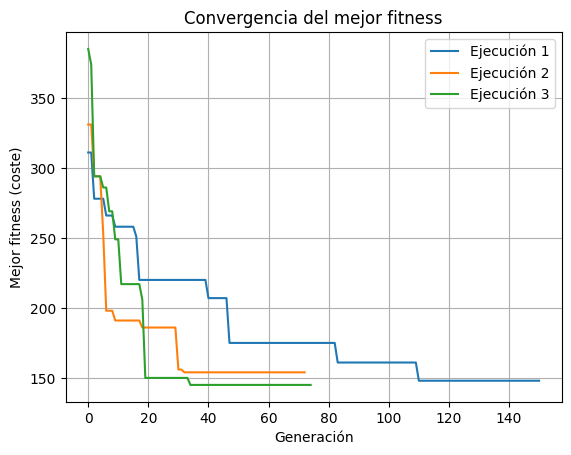

In [10]:
# Mejor fitness de cada ejecucion
for i, hist in enumerate(historiales_mejor):
    plt.plot(hist, label=f'Ejecución {i+1}')
plt.xlabel('Generación')
plt.ylabel('Mejor fitness (coste)')
plt.title('Convergencia del mejor fitness')
plt.legend()
plt.grid(True)
plt.show()

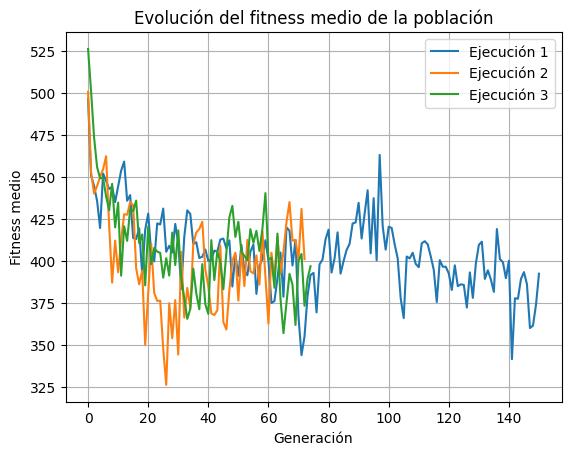

In [11]:
# Fitness medio de cada ejecucion
for i, hist in enumerate(historiales_media):
    plt.plot(hist, label=f'Ejecución {i+1}')
plt.xlabel('Generación')
plt.ylabel('Fitness medio')
plt.title('Evolución del fitness medio de la población')
plt.legend()
plt.grid(True)
plt.show()

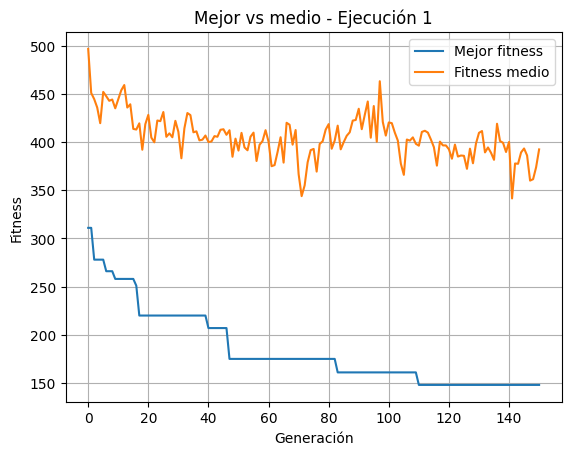

In [12]:
# Mejor vs media para la ejecucion 1 (para ver la diferencia)
plt.plot(historiales_mejor[0], label='Mejor fitness')
plt.plot(historiales_media[0], label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Mejor vs medio - Ejecución 1')
plt.legend()
plt.grid(True)
plt.show()

### 4.2 Análisis de resultados

In [13]:
fitness_obtenidos = [r[1] for r in resultados]

print("RESUMEN DE LAS 3 EJECUCIONES")
print("=" * 40)
for i, (sol, fit) in enumerate(resultados):
    print(f"Ejecución {i+1}: coste = {fit}, solución = {sol}")

print(f"\nMejor coste:  {min(fitness_obtenidos)}")
print(f"Peor coste:   {max(fitness_obtenidos)}")
print(f"Media:        {np.mean(fitness_obtenidos):.2f}")
print(f"Desv. típica: {np.std(fitness_obtenidos):.2f}")

RESUMEN DE LAS 3 EJECUCIONES
Ejecución 1: coste = 148, solución = [2 1 6 5 9 7 3 0 4 8]
Ejecución 2: coste = 154, solución = [2 9 8 5 6 0 3 1 4 7]
Ejecución 3: coste = 145, solución = [2 9 6 1 5 0 3 4 7 8]

Mejor coste:  145
Peor coste:   154
Media:        149.00
Desv. típica: 3.74


In [14]:
# Detalle de la mejor solucion encontrada
mejor_idx = fitness_obtenidos.index(min(fitness_obtenidos))
mejor_sol = resultados[mejor_idx][0]
mejor_fit = resultados[mejor_idx][1]

print(f"MEJOR SOLUCIÓN ENCONTRADA (ejecución {mejor_idx+1})")
print("=" * 40)
print(f"Asignación: {mejor_sol}")
print(f"Coste total: {mejor_fit}")
print()
for trabajador, tarea in enumerate(mejor_sol):
    c = costes[trabajador][tarea]
    print(f"  Trabajador {trabajador} -> Tarea {tarea} (coste: {c})")

MEJOR SOLUCIÓN ENCONTRADA (ejecución 3)
Asignación: [2 9 6 1 5 0 3 4 7 8]
Coste total: 145

  Trabajador 0 -> Tarea 2 (coste: 15)
  Trabajador 1 -> Tarea 9 (coste: 2)
  Trabajador 2 -> Tarea 6 (coste: 22)
  Trabajador 3 -> Tarea 1 (coste: 42)
  Trabajador 4 -> Tarea 5 (coste: 7)
  Trabajador 5 -> Tarea 0 (coste: 4)
  Trabajador 6 -> Tarea 3 (coste: 8)
  Trabajador 7 -> Tarea 4 (coste: 4)
  Trabajador 8 -> Tarea 7 (coste: 15)
  Trabajador 9 -> Tarea 8 (coste: 26)


### 4.3 Análisis de estabilidad y calidad de las soluciones

Mirando los resultados de las 3 ejecuciones:

- Los tres costes están bastante cerca unos de otros. La desviación típica es de solo 3.74 sobre una media de 149, así que el algoritmo no da resultados muy distintos según la semilla. Eso me dice que es **estable**.
- En cuanto a **calidad**, si la matriz tiene valores entre 1 y 99, el valor medio de una celda es más o menos 50. Para 10 asignaciones eso serían unos 500 de coste esperado si asignas al azar. El AG consigue bajarlo a ~149, o sea unos 15 de media por asignación, que está bastante bien.
- En las gráficas se ve que las primeras 10-15 generaciones es donde más baja el coste, y después se va quedando plano hasta que salta la parada por estancamiento. 
- La gráfica de mejor vs medio muestra cómo la media se va acercando al mejor conforme pasan las generaciones. Eso quiere decir que la población entera va mejorando, no solo el mejor individuo.
- Las 3 ejecuciones llegan a costes parecidos por caminos distintos, lo que da cierta confianza en que no se está quedando pillado en un mínimo local malo.

---
## 5. Conclusiones

### Sobre el comportamiento del algoritmo

El AG baja bastante rápido el coste en las primeras generaciones y luego se estanca. El criterio de parada por estancamiento hace bien su trabajo aquí, porque si no estaría dando vueltas sin mejorar.

El elitismo se nota mucho. Probé a quitarlo y el coste final era peor y más variable entre ejecuciones. Tiene sentido porque en la Sesión 4 – Estrategias de Reemplazo Generacional ya se veía que el generacional sin elitismo pierde buenas soluciones.

### Sobre las decisiones de diseño tomadas

- **Permutaciones**: era la forma más directa de representar las soluciones. Igual que en el Problema del Viajero de la Sesión 3, cada individuo es una permutación y ya está.
- **Torneo k=3**: lo he cogido de la Sesión 3 – Aplicación al Problema del Viajero. Funciona bien y es fácil de implementar. No he probado otros valores de k la verdad, pero con 3 va bien.
- **Cruce OX**: es el que aparece en la Sesión 3 – Aplicación al Problema del Viajero, en la Sesión 4 – Estrategias de Reemplazo Generacional y en la Sesión 6 – Hiperparametrización. Siempre da permutaciones válidas y no es complicado.
- **Mutación swap**: la misma de la Sesión 3. La probabilidad de 0.15 la puse un poco a ojo, quizá es algo alta pero me pareció que así mantenía más variedad en la población.
- **Elitismo**: después de ver la comparativa de la Sesión 4 – Estrategias de Reemplazo Generacional tenía claro que quería usarlo.
- **Parada por estancamiento**: sacado de la Sesión 5 – Criterios de parada (Problema de la Mochila). El de entropía también me parecía interesante pero al final me quedé con el de falta de mejora porque es más sencillo.

### Sobre posibles mejoras y vías de investigación

- Se podría probar el **modelo (μ + λ)** que aparece en la Sesión 4 – Estrategias de Reemplazo Generacional, donde padres e hijos compiten juntos. A lo mejor da resultados un poco mejores que el generacional con elitismo.
- Otra cosa sería ir **cambiando la probabilidad de mutación** durante la ejecución: empezar más alto para explorar bien y bajarlo cuando ya está convergiendo.
- También se podría meter la **entropía genética** como criterio de parada, como se hace en la Sesión 5 – Criterios de parada (Problema de la Mochila). Así se pararía cuando la población se ha vuelto demasiado homogénea.
- Para problemas más grandes (50 o 100 trabajadores) habría que tocar los parámetros seguro, más población y más generaciones. Incluso se podría usar el meta-GA de la Sesión 6 – Hiperparametrización para encontrar buenos parámetros automáticamente.
- Y bueno, también se podría combinar el AG con una búsqueda local para pulir la solución una vez que el AG ya no mejora más.